### Recommendation System Project

### Problem Statement :

Build your own recommendation system for products on an e-commerce website like Amazon.com. 

### Dataset columns :
First three columns are userId, productId, and ratings and the fourth column is timestamp. You can discard the timestamp column as in this case you may not need to use it.

Source - Amazon Reviews data (http://jmcauley.ucsd.edu/data/amazon/).

 

Dataset Link - https://drive.google.com/file/d/1ClBptsK3V5KgKXtK2GSRzFNAW7GnTPDW/view?usp=sharing

Please do the analysis based on steps( 1 to 8) as given below  using a NEW python notebook:

Steps :

1. Read and explore the given dataset.  ( Rename column/add headers, plot histograms, find data characteristics)
2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )
3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)
4. Build Popularity Recommender model.
5. Build Collaborative Filtering model.
6. Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE)  on predictions made on the test data.) You can also use a different method to evaluate the models.
7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.
8. Summarise your insights.
 

Please Note - 

If you are facing any memory issue while working on this project, create a small subset (Let’s say 10% of data) and work on it.

In [311]:
%matplotlib inline

import pandas as pd
import numpy as np

import time
from sklearn.externals import joblib

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
import Recommenders as Recommenders
import Evaluation as Evaluation

### 1. Read and explore the given dataset. ( Rename column/add headers, plot histograms, find data characteristics)

In [152]:
#Read rating data from CSV file and  set column name like as given ("User_id","Product_id","Ratings","Timestamp")
column=["user_id","product_id","ratings","timestamp"]
ratings_data_Full = pd.read_csv('ratings_Electronics.csv',header=None,names =column)

In [153]:
#Get shape of the full rating dataset
ratings_data_Full.shape

(7824482, 4)

In the rating full dataset we have 78,24,482 rows and 4 columns.

Since data set is very huge this will give memory issue if we use this full data set. 

Due to that we will use subset of data from full size, let use 5% of random sampling from full dataset, which means we will use just 391224 rows as sample for this project.

In [154]:
ratings_data_Full.head(5)

,user_id,product_id,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [197]:
#Drop timestamp column which not required for modeling

ratings_data_Full=ratings_data_Full.drop(columns=['timestamp'])

In [281]:
# ** Get sample of 10% of data from rating full dataset **

#Sample method returns a random sample of items from an axis of object and this object of same type as your caller.
# we can do fraction of axis items and get rows. For example, if frac= .10 then sample method return 10% of rows.
# As said,above we will use 782448 rows 

rating_df=ratings_data_Full.sample(frac =.10)

In [282]:
rating_df.shape

(782448, 3)

In [283]:
rating_df.head()

,user_id,product_id,ratings
3059266,A1B6II3OG0HZ0O,B00358PRCA,1.0
4945790,A1H2RGOZWSCYL9,B005GSPN6M,5.0
5587281,A1NLOQX66DOU08,B00746W3HG,3.0
1655751,A373LC50LRSK9M,B0013TS0T0,3.0
2703421,A1MZK1A43HT4RB,B002MAPRYU,5.0


In [284]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 782448 entries, 3059266 to 6280486
Data columns (total 3 columns):
user_id       782448 non-null object
product_id    782448 non-null object
ratings       782448 non-null float64
dtypes: float64(1), object(2)
memory usage: 23.9+ MB


In [285]:
#Get Number of unique product in the rating dataset
print("Total Number of Unique Product  : {0}".format(rating_df.product_id.nunique()))

Total Number of Unique Product  : 167412


In [286]:
#Get number of unique user who's given rating
print("Total Number of Unique User who's Given Rating  : {0}".format(rating_df.user_id.nunique()))

Total Number of Unique User who's Given Rating  : 672471


In [287]:
rating_df.ratings.nunique()

5

In [288]:
rating_df.ratings.value_counts()

5.0    435218
4.0    148446
1.0     90020
3.0     62910
2.0     45854
Name: ratings, dtype: int64

In [211]:
flights_df.hist('ratings', bins=20);

NameError: name 'flights_df' is not defined

In [164]:
#Drop if any duplicate in the data set
rating_df=rating_df.drop_duplicates(subset=['product_id', 'user_id','ratings'], keep='first')

In [165]:
#Look there is no duplicate in the rating data set
rating_df.shape

(782448, 3)

### 2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )

In [289]:
user_count =rating_df.user_id.value_counts()
df_user_count = pd.DataFrame(user_count).reset_index()
df_user_count.columns = ['user_id', 'counts']



In [290]:
df_user_count.head(20)

,user_id,counts
0,A5JLAU2ARJ0BO,53
1,A6FIAB28IS79,50
2,ADLVFFE4VBT8,48
3,A3OXHLG6DIBRW8,40
4,AWPODHOB4GFWL,35
5,A680RUE1FDO8B,35
6,A36K2N527TXXJN,35
7,A3EXWV8FNSSFL6,34
8,A1ODOGXEYECQQ8,33
9,ABDR6IJ93HFIO,33


In [291]:
#Get unique user who has given 10 or more ratings
df_user_count=df_user_count[df_user_count.counts >=10]

In [292]:
#
rating_df_subset=rating_df[rating_df.user_id.isin(df_user_count.user_id)]

In [293]:
rating_df_subset.shape

(5891, 3)

In [294]:
rating_df_subset.head()

,user_id,product_id,ratings
5994910,A3PD8JD9L4WEII,B007ZZAMAQ,4.0
685088,ABQWMANK4AR63,B0009TQB00,5.0
4970739,A2VODABWSVHV8E,B005HMKKH4,5.0
6103096,A2QRXQPHDMFCQV,B00884WH74,4.0
3871618,A2AY4YUOX2N1BQ,B0044XTJ10,5.0


### 3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)

In [295]:
train_data, test_data = train_test_split(rating_df_subset, test_size = 0.30, random_state=0)
print(train_data.head(5))

                user_id  product_id  ratings
6399519  A17V9XL4CWTQ6G  B008X9Z528      4.0
6094360   AG35JCCQWDRCS  B0087N46XY      3.0
6503810  A206CGM6J75UJY  B0096YOQQA      2.0
4980021  A1SB9BNNGKNX2Z  B005HSDLCO      5.0
544092   A2UTZ4O5E2W4DK  B00065ANYC      5.0


In [296]:
print("Train data shape : {0}".format(train_data.shape))

Train data shape : (4123, 3)


In [297]:
print("Test data shape : {0}".format(test_data.shape))

Test data shape : (1768, 3)


### 4. Build Popularity Recommender model

In [298]:
#Class for Popularity based Recommender System model
class popularity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.popularity_recommendations = None
        
    #Create the popularity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

        #Get a count of user_ids for each unique product as recommendation score
        train_data_grouped = train_data.groupby([self.item_id]).agg({self.user_id: 'count'}).reset_index()
        train_data_grouped.rename(columns = {self.user_id: "score"},inplace=True)
        #Sort the products based upon recommendation score
        print(train_data_grouped.head())
        print(self.item_id)
        train_data_sort = train_data_grouped.sort_values(by=["score", self.item_id], ascending=[0,1])
    
        #Generate a recommendation rank based upon score
        train_data_sort['Rank'] = train_data_sort['score'].rank(ascending=0, method='first')
        
        #Get the top 10 recommendations
        self.popularity_recommendations = train_data_sort.head(10)

    #Use the popularity based recommender system model to
    #make recommendations
    def recommend(self, user_id):    
        user_recommendations = self.popularity_recommendations
        
        #Add user_id column for which the recommendations are being generated
        user_recommendations[self.user_id] = user_id
    
        #Bring user_id column to the front
        cols = user_recommendations.columns.tolist()
        cols = cols[-1:] + cols[:-1]
        user_recommendations = user_recommendations[cols]
        
        return user_recommendations




In [299]:
pm = popularity_recommender_py()
pm.create(train_data, 'user_id', 'product_id')

   product_id  score
0  1400501776      1
1  1400599997      1
2  B00000J061      1
3  B00000J434      1
4  B00000J4FS      1
product_id


In [300]:
users=train_data.user_id.unique()

In [301]:
user_id = users[20]
pm.recommend(user_id)

,user_id,product_id,score,Rank
1518,AVFJ327UXPXLF,B002R5AM7C,9,1.0
2722,AVFJ327UXPXLF,B0088CJT4U,8,2.0
699,AVFJ327UXPXLF,B000LRMS66,5,3.0
730,AVFJ327UXPXLF,B000N99BBC,5,4.0
810,AVFJ327UXPXLF,B000S5Q9CA,5,5.0
881,AVFJ327UXPXLF,B000VX6XL6,5,6.0
1091,AVFJ327UXPXLF,B001CHHVCU,5,7.0
1996,AVFJ327UXPXLF,B004CLYEE6,5,8.0
2324,AVFJ327UXPXLF,B005FYNSPK,5,9.0
2340,AVFJ327UXPXLF,B005HMKKH4,5,10.0


In [302]:
user_id = users[50]
pm.recommend(user_id)

,user_id,product_id,score,Rank
1518,A4WEZJOIZIV4U,B002R5AM7C,9,1.0
2722,A4WEZJOIZIV4U,B0088CJT4U,8,2.0
699,A4WEZJOIZIV4U,B000LRMS66,5,3.0
730,A4WEZJOIZIV4U,B000N99BBC,5,4.0
810,A4WEZJOIZIV4U,B000S5Q9CA,5,5.0
881,A4WEZJOIZIV4U,B000VX6XL6,5,6.0
1091,A4WEZJOIZIV4U,B001CHHVCU,5,7.0
1996,A4WEZJOIZIV4U,B004CLYEE6,5,8.0
2324,A4WEZJOIZIV4U,B005FYNSPK,5,9.0
2340,A4WEZJOIZIV4U,B005HMKKH4,5,10.0


### 5. Build Collaborative Filtering model.

In [305]:
#Class for Item similarity based Recommender System model
class item_similarity_recommender_py():
    def __init__(self):
        self.train_data = None
        self.user_id = None
        self.item_id = None
        self.cooccurence_matrix = None
        self.items_dict = None
        self.rev_items_dict = None
        self.item_similarity_recommendations = None
        
    #Get unique items (products) corresponding to a given user
    def get_user_items(self, user):
        user_data = self.train_data[self.train_data[self.user_id] == user]
        user_items = list(user_data[self.item_id].unique())
        
        return user_items
        
    #Get unique users for a given item (product)
    def get_item_users(self, item):
        item_data = self.train_data[self.train_data[self.item_id] == item]
        item_users = set(item_data[self.user_id].unique())
            
        return item_users
        
    #Get unique items (products) in the training data
    def get_all_items_train_data(self):
        all_items = list(self.train_data[self.item_id].unique())
            
        return all_items
        
    #Construct cooccurence matrix
    def construct_cooccurence_matrix(self, user_items, all_items):
            
        ####################################
        #Get users for all products in user_items.
        ####################################
        user_items_users = []        
        for i in range(0, len(user_items)):
            user_items_users.append(self.get_item_users(user_items[i]))
            
        ###############################################
        #Initialize the item cooccurence matrix of size 
        #len(user_items) X len(items)
        ###############################################
        cooccurence_matrix = np.matrix(np.zeros(shape=(len(user_items), len(all_items))), float)
           
        #############################################################
        #Calculate similarity between user items and all unique items
        #in the training data
        #############################################################
        for i in range(0,len(all_items)):
            #Calculate unique listeners (users) of item (product) i
            items_i_data = self.train_data[self.train_data[self.item_id] == all_items[i]]
            users_i = set(items_i_data[self.user_id].unique())
            
            for j in range(0,len(user_items)):       
                    
                #Get unique listeners (users) of item (product) j
                users_j = user_items_users[j]
                    
                #Calculate intersection of listeners of items i and j
                users_intersection = users_i.intersection(users_j)
                
                #Calculate cooccurence_matrix[i,j] as Jaccard Index
                if len(users_intersection) != 0:
                    #Calculate union of listeners of items i and j
                    users_union = users_i.union(users_j)
                    
                    cooccurence_matrix[j,i] = float(len(users_intersection))/float(len(users_union))
                else:
                    cooccurence_matrix[j,i] = 0
                    
        
        return cooccurence_matrix

    
    #Use the cooccurence matrix to make top recommendations
    def generate_top_recommendations(self, user, cooccurence_matrix, all_items, user_items):
        print("Non zero values in cooccurence_matrix :%d" % np.count_nonzero(cooccurence_matrix))
        
        #Calculate a weighted average of the scores in cooccurence matrix for all user items.
        user_sim_scores = cooccurence_matrix.sum(axis=0)/float(cooccurence_matrix.shape[0])
        user_sim_scores = np.array(user_sim_scores)[0].tolist()
 
        #Sort the indices of user_sim_scores based upon their value
        #Also maintain the corresponding score
        sort_index = sorted(((e,i) for i,e in enumerate(list(user_sim_scores))), reverse=True)
    
        #Create a dataframe from the following
        columns = ['user_id', 'product_id', 'score', 'rank']
        #index = np.arange(1) # array of numbers for the number of samples
        df = pd.DataFrame(columns=columns)
         
        #Fill the dataframe with top 10 item based recommendations
        rank = 1 
        for i in range(0,len(sort_index)):
            if ~np.isnan(sort_index[i][0]) and all_items[sort_index[i][1]] not in user_items and rank <= 10:
                df.loc[len(df)]=[user,all_items[sort_index[i][1]],sort_index[i][0],rank]
                rank = rank+1
        
        #Handle the case where there are no recommendations
        if df.shape[0] == 0:
            print("The current user has no products for training the item similarity based recommendation model.")
            return -1
        else:
            return df
 
    #Create the item similarity based recommender system model
    def create(self, train_data, user_id, item_id):
        self.train_data = train_data
        self.user_id = user_id
        self.item_id = item_id

    #Use the item similarity based recommender system model to
    #make recommendations
    def recommend(self, user):
        
        ########################################
        #A. Get all unique products for this user
        ########################################
        user_items = self.get_user_items(user)    
            
        print("No. of unique products for the user: %d" % len(user_items))
        
        ######################################################
        #B. Get all unique items (products) in the training data
        ######################################################
        all_items = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_items))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_items) X len(items)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_items, all_items)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_items, user_items)
                
        return df_recommendations
    
    #Get similar items to given items
    def get_similar_items(self, item_list):
        
        user_items = item_list
        
        ######################################################
        #B. Get all unique items (products) in the training data
        ######################################################
        all_items = self.get_all_items_train_data()
        
        print("no. of unique products in the training set: %d" % len(all_items))
         
        ###############################################
        #C. Construct item cooccurence matrix of size 
        #len(user_items) X len(items)
        ###############################################
        cooccurence_matrix = self.construct_cooccurence_matrix(user_items, all_items)
        
        #######################################################
        #D. Use the cooccurence matrix to make recommendations
        #######################################################
        user = ""
        df_recommendations = self.generate_top_recommendations(user, cooccurence_matrix, all_items, user_items)
         
        return df_recommendations

In [306]:
#Create an instance of item similarity based recommender class
is_model = item_similarity_recommender_py()
is_model.create(train_data, 'user_id', 'product_id')

In [308]:
#Print the products for the user in training data
user_id = users[50]
user_items = is_model.get_user_items(user_id)
#
print("------------------------------------------------------------------------------------")
print("Training data products for the user userid: %s:" % user_id)
print("------------------------------------------------------------------------------------")

for user_item in user_items:
    print(user_item)

print("----------------------------------------------------------------------")
print("Recommendation process going on:")
print("----------------------------------------------------------------------")

#Recommend products for the user using personalized model
is_model.recommend(user_id)

------------------------------------------------------------------------------------
Training data products for the user userid: A4WEZJOIZIV4U:
------------------------------------------------------------------------------------
B0093HMKVI
B003MVYTBU
B00D5Q75RC
B00E3W15P0
B000BQ7GW8
B005P5UMVM
B000V9D5LG
B004LPY204
B00B7QC108
B00008XPAR
----------------------------------------------------------------------
Recommendation process going on:
----------------------------------------------------------------------
No. of unique products for the user: 10
no. of unique products in the training set: 3567
Non zero values in cooccurence_matrix :120


,user_id,product_id,score,rank
0,A4WEZJOIZIV4U,B004X28I0A,0.050000,1
1,A4WEZJOIZIV4U,B00AW54Z4K,0.050000,2
2,A4WEZJOIZIV4U,B004SCRC98,0.050000,3
3,A4WEZJOIZIV4U,B0000X0VU6,0.050000,4
4,A4WEZJOIZIV4U,B000ARSLB8,0.050000,5
5,A4WEZJOIZIV4U,B0062IMAQ6,0.050000,6
6,A4WEZJOIZIV4U,B000VWKSFE,0.050000,7
7,A4WEZJOIZIV4U,B0043BNWNE,0.033333,8
8,A4WEZJOIZIV4U,B001IZZ7M2,0.033333,9
9,A4WEZJOIZIV4U,B003VAM32E,0.033333,10


### 6. Evaluate both the models. 
( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on predictions made on the test data.) 

You can also use a different method to evaluate the models.

In [317]:
#Class to calculate precision and recall

import random

class precision_recall_calculator():
    
    def __init__(self, test_data, train_data, pm, is_model):
        self.test_data = test_data
        self.train_data = train_data
        self.user_test_sample = None
        self.model1 = pm
        self.model2 = is_model
        
        self.ism_training_dict = dict()
        self.pm_training_dict = dict()
        self.test_dict = dict()
    
    #Method to return random percentage of values from a list
    def remove_percentage(self, list_a, percentage):
        k = int(len(list_a) * percentage)
        random.seed(0)
        indicies = random.sample(range(len(list_a)), k)
        new_list = [list_a[i] for i in indicies]
    
        return new_list
    
    #Create a test sample of users for use in calculating precision
    #and recall
    def create_user_test_sample(self, percentage):
        #Find users common between training and test set
        users_test_and_training = list(set(self.test_data['user_id'].unique()).intersection(set(self.train_data['user_id'].unique())))
        print("Length of user_test_and_training:%d" % len(users_test_and_training))

        #Take only random user_sample of users for evaluations
        self.users_test_sample = self.remove_percentage(users_test_and_training, percentage)

        print("Length of user sample:%d" % len(self.users_test_sample))
        
    #Method to generate recommendations for users in the user test sample
    def get_test_sample_recommendations(self):
        #For these test_sample users, get top 10 recommendations from training set
        #self.ism_training_dict = {}
        #self.pm_training_dict = {}

        #self.test_dict = {}

        for user_id in self.users_test_sample:
            #Get items for user_id from item similarity model
            print("Getting recommendations for user:%s" % user_id)
            user_sim_items = self.model2.recommend(user_id)
            print(user_sim_items)
            self.ism_training_dict[user_id] = list(user_sim_items["product_id"])
    
            #Get items for user_id from popularity model
            user_sim_items = self.model1.recommend(user_id)
            print(user_sim_items)
            self.pm_training_dict[user_id] = list(user_sim_items["product_id"])
    
            #Get items for user_id from test_data
            test_data_user = self.test_data[self.test_data['user_id'] == user_id]
            self.test_dict[user_id] = set(test_data_user['product_id'].unique() )
    
    #Method to calculate the precision and recall measures
    def calculate_precision_recall(self):
        #Create cutoff list for precision and recall calculation
        cutoff_list = list(range(1,11))


        #For each distinct cutoff:
        #    1. For each distinct user, calculate precision and recall.
        #    2. Calculate average precision and recall.

        ism_avg_precision_list = []
        ism_avg_recall_list = []
        pm_avg_precision_list = []
        pm_avg_recall_list = []


        num_users_sample = len(self.users_test_sample)
        for N in cutoff_list:
            ism_sum_precision = 0
            ism_sum_recall = 0
            pm_sum_precision = 0
            pm_sum_recall = 0
            ism_avg_precision = 0
            ism_avg_recall = 0
            pm_avg_precision = 0
            pm_avg_recall = 0

            for user_id in self.users_test_sample:
                ism_hitset = self.test_dict[user_id].intersection(set(self.ism_training_dict[user_id][0:N]))
                pm_hitset = self.test_dict[user_id].intersection(set(self.pm_training_dict[user_id][0:N]))
                testset = self.test_dict[user_id]
        
                pm_sum_precision += float(len(pm_hitset))/float(N)
                pm_sum_recall += float(len(pm_hitset))/float(len(testset))

                ism_sum_precision += float(len(ism_hitset))/float(len(testset))
                ism_sum_recall += float(len(ism_hitset))/float(N)
        
            pm_avg_precision = pm_sum_precision/float(num_users_sample)
            pm_avg_recall = pm_sum_recall/float(num_users_sample)
    
            ism_avg_precision = ism_sum_precision/float(num_users_sample)
            ism_avg_recall = ism_sum_recall/float(num_users_sample)

            ism_avg_precision_list.append(ism_avg_precision)
            ism_avg_recall_list.append(ism_avg_recall)
    
            pm_avg_precision_list.append(pm_avg_precision)
            pm_avg_recall_list.append(pm_avg_recall)
            
        return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)
     

    #A wrapper method to calculate all the evaluation measures
    def calculate_measures(self, percentage):
        #Create a test sample of users
        self.create_user_test_sample(percentage)
        
        #Generate recommendations for the test sample users
        self.get_test_sample_recommendations()
        
        #Calculate precision and recall at different cutoff values
        #for popularity mode (pm) as well as item similarity model (ism)
        
        return self.calculate_precision_recall()
        #return (pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list)    

In [318]:
start = time.time()

#Define what percentage of users to use for precision recall calculation
user_sample = 0.01

#Instantiate the precision_recall_calculator class
pr = precision_recall_calculator(test_data, train_data, pm, is_model)

#Call method to calculate precision and recall values
(pm_avg_precision_list, pm_avg_recall_list, ism_avg_precision_list, ism_avg_recall_list) = pr.calculate_measures(user_sample)

end = time.time()
print(end - start)

Length of user_test_and_training:392
Length of user sample:3
Getting recommendations for user:AEAFHD09X8044
No. of unique products for the user: 9
no. of unique products in the training set: 3567
Non zero values in cooccurence_matrix :81
         user_id  product_id  score rank
0  AEAFHD09X8044  B0000XMW8U    0.0    1
1  AEAFHD09X8044  B00001TZYI    0.0    2
2  AEAFHD09X8044  B00KI2BD1U    0.0    3
3  AEAFHD09X8044  B007FGH6WM    0.0    4
4  AEAFHD09X8044  B005LAIEN4    0.0    5
5  AEAFHD09X8044  B000VUIXOO    0.0    6
6  AEAFHD09X8044  B008RZ0EQ0    0.0    7
7  AEAFHD09X8044  B001TOD3KU    0.0    8
8  AEAFHD09X8044  B0080JQY4O    0.0    9
9  AEAFHD09X8044  B003WOCIEM    0.0   10
            user_id  product_id  score  Rank
1518  AEAFHD09X8044  B002R5AM7C      9   1.0
2722  AEAFHD09X8044  B0088CJT4U      8   2.0
699   AEAFHD09X8044  B000LRMS66      5   3.0
730   AEAFHD09X8044  B000N99BBC      5   4.0
810   AEAFHD09X8044  B000S5Q9CA      5   5.0
881   AEAFHD09X8044  B000VX6XL6      5   

In [319]:
import pylab as pl

#Method to generate precision and recall curve
def plot_precision_recall(m1_precision_list, m1_recall_list, m1_label, m2_precision_list, m2_recall_list, m2_label):
    pl.clf()    
    pl.plot(m1_recall_list, m1_precision_list, label=m1_label)
    pl.plot(m2_recall_list, m2_precision_list, label=m2_label)
    pl.xlabel('Recall')
    pl.ylabel('Precision')
    pl.ylim([0.0, 0.2])
    pl.xlim([0.0, 0.2])
    pl.title('Precision-Recall curve')
    #pl.legend(loc="upper right")
    pl.legend(loc=9, bbox_to_anchor=(0.5, -0.2))
    pl.show()

Plotting precision recall curves.


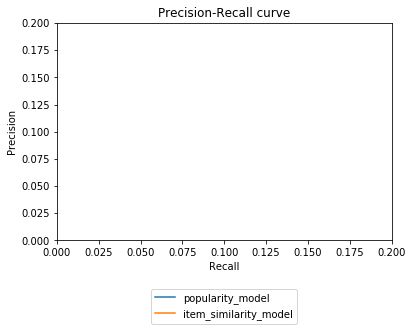

In [320]:
print("Plotting precision recall curves.")

plot_precision_recall(pm_avg_precision_list, pm_avg_recall_list, "popularity_model",
                      ism_avg_precision_list, ism_avg_recall_list, "item_similarity_model")

### 7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.

### 8.Summarise your insights.